In [12]:
!pip install statsbombpy mplsoccer matplotlib pandas -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch

# Match ID StatsBomb: Finale World Cup 2022 (Argentina vs Francia)
MATCH_ID = 3869685

print("Scaricamento eventi in corso da StatsBomb...")
events = sb.events(match_id=MATCH_ID)
print(f"Dataset pronto: {len(events)} eventi registrati.")
print("Squadre:", events['team'].dropna().unique())

Scaricamento eventi in corso da StatsBomb...
Dataset pronto: 4407 eventi registrati.
Squadre: ['Argentina' 'France']


Expected Goals Cumulati (120 min):
team
Argentina    2.76
France       2.27
Name: shot_statsbomb_xg, dtype: float64


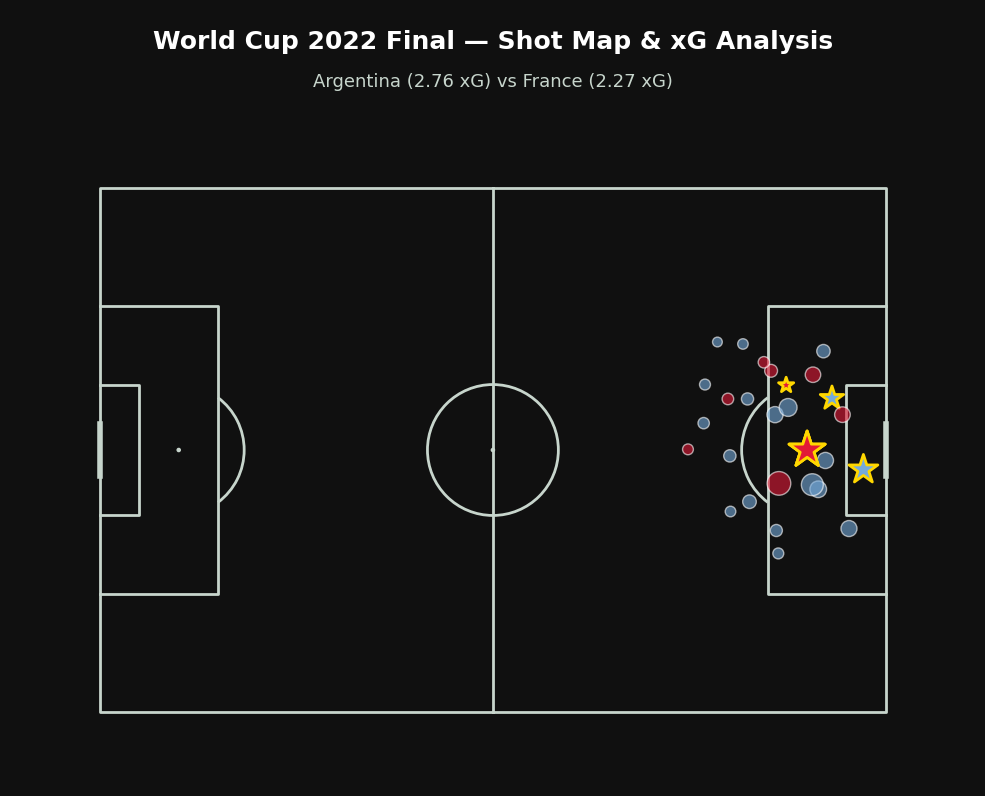

In [13]:
# 1. Filtro tiri escludendo i calci di rigore post-supplementari
shots = events[(events['type'] == 'Shot') & (events['period'] <= 4)].copy()

# Estrazione coordinate x e y di tiro
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
shots['is_goal'] = shots['shot_outcome'] == 'Goal'

# Calcolo xG cumulato per squadra
xg_totali = shots.groupby('team')['shot_statsbomb_xg'].sum().round(2)
print("Expected Goals Cumulati (120 min):")
print(xg_totali)

# 2. Visualizzazione con Pitch di mplsoccer
pitch = Pitch(pitch_type='statsbomb', pitch_color='#101010', line_color='#c7d5cc')
fig, axs = pitch.jointgrid(figheight=8, left=None, bottom=None,
                           grid_height=0.8, axis=False,
                           title_height=0.1, endnote_height=0.05)
fig.set_facecolor('#101010')

teams = ['Argentina', 'France']
colors = {'Argentina': '#75AADB', 'France': '#E21A37'}

for team in teams:
    team_shots = shots[shots['team'] == team]

    # Tiri non trasformati in gol (bolle trasparenti)
    non_goals = team_shots[~team_shots['is_goal']]
    pitch.scatter(non_goals['x'], non_goals['y'],
                  s=(non_goals['shot_statsbomb_xg'] * 900) + 40,
                  c=colors[team], alpha=0.6, edgecolors='#ffffff',
                  linewidth=1, ax=axs['pitch'], label=f"{team} (Tiri)")

    # Gol segnati (bolle piene bordate di giallo/oro)
    goals = team_shots[team_shots['is_goal']]
    pitch.scatter(goals['x'], goals['y'],
                  s=(goals['shot_statsbomb_xg'] * 900) + 40,
                  c=colors[team], marker='*', edgecolors='#FFD700',
                  linewidth=2, ax=axs['pitch'], label=f"{team} (Gol)")

# Intestazione grafica
axs['title'].text(0.5, 0.6, 'World Cup 2022 Final — Shot Map & xG Analysis',
                  ha='center', va='center', fontsize=18, color='#ffffff', weight='bold')
axs['title'].text(0.5, 0.1, f"Argentina ({xg_totali.get('Argentina', 0)} xG) vs France ({xg_totali.get('France', 0)} xG)",
                  ha='center', va='center', fontsize=13, color='#c7d5cc')

plt.savefig('shot_map_xg.png', dpi=300, bbox_inches='tight', facecolor='#101010')
plt.show()

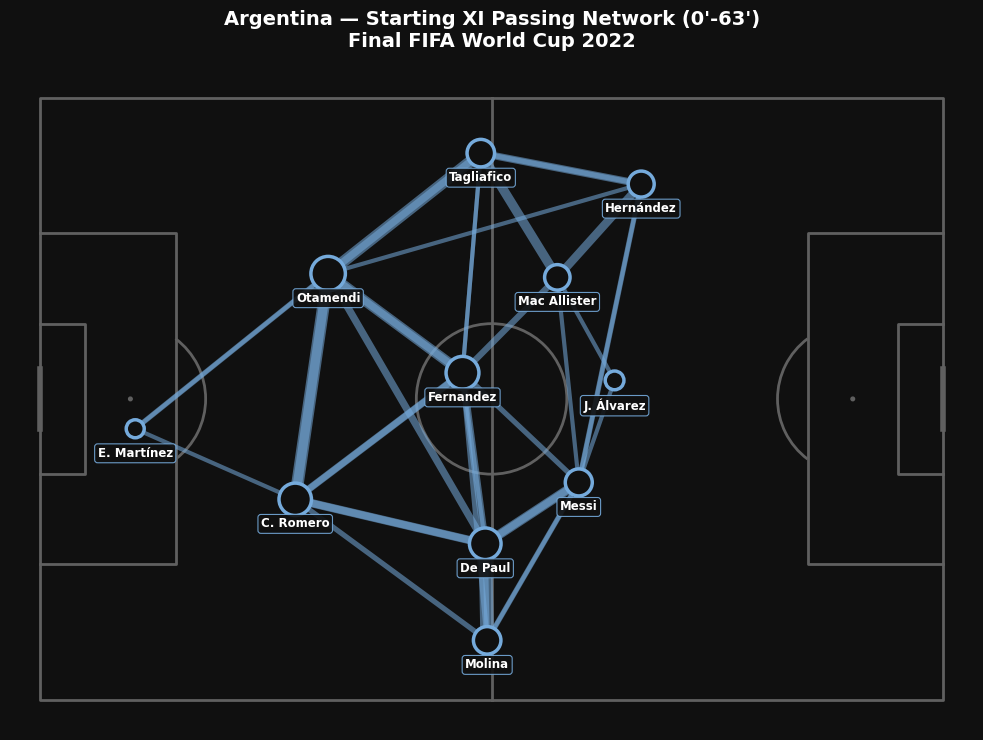

In [14]:
# 1. Filtro passaggi riusciti dell'Argentina (0' - prima sostituzione al 64')
sub_minute = events[(events['team'] == 'Argentina') &
                    (events['type'] == 'Substitution')]['minute'].min()

passes = events[(events['team'] == 'Argentina') &
                (events['type'] == 'Pass') &
                (events['pass_outcome'].isna()) &
                (events['minute'] < sub_minute)].copy()

# Escludiamo eventuali passaggi non indirizzati a compagni argentini
passes = passes[passes['pass_recipient'].isin(passes['player'].unique())]

passes['x'] = passes['location'].apply(lambda loc: loc[0])
passes['y'] = passes['location'].apply(lambda loc: loc[1])

# 2. Mappatura corretta e pulita dei nomi dei titolari argentini
nomi_puliti = {
    'Damián Emiliano Martínez': 'E. Martínez',
    'Nahuel Molina Lucero': 'Molina',
    'Cristian Gabriel Romero': 'C. Romero',
    'Nicolás Hernán Otamendi': 'Otamendi',
    'Nicolás Alejandro Tagliafico': 'Tagliafico',
    'Rodrigo Javier De Paul': 'De Paul',
    'Enzo Jeremias Fernandez': 'E. Fernández',
    'Alexis Mac Allister': 'Mac Allister',
    'Ángel Fabián Di María': 'Di María',
    'Lionel Andrés Messi Cuccittini': 'Messi',
    'Julián Álvarez': 'J. Álvarez'
}

# 3. Coordinate medie e volume passaggi
avg_locations = passes.groupby('player').agg({'x': 'mean', 'y': 'mean', 'id': 'count'})
avg_locations.rename(columns={'id': 'count'}, inplace=True)

# 4. Calcolo scambi tra coppie
pass_between = passes.groupby(['player', 'pass_recipient']).id.count().reset_index()
pass_between.rename(columns={'id': 'pass_count'}, inplace=True)

pass_between = pass_between.merge(avg_locations, left_on='player', right_index=True)
pass_between = pass_between.merge(avg_locations, left_on='pass_recipient', right_index=True, suffixes=['', '_end'])

# Connessioni rilevanti (almeno 4 passaggi)
pass_between = pass_between[pass_between['pass_count'] >= 4]

# 5. Visualizzazione su campo
pitch = Pitch(pitch_type='statsbomb', pitch_color='#101010', line_color='#606060')
fig, ax = pitch.draw(figsize=(11, 7.5))
fig.set_facecolor('#101010')

# Linee di passaggio
pitch.lines(pass_between.x, pass_between.y,
            pass_between.x_end, pass_between.y_end,
            lw=pass_between.pass_count * 0.75,
            color='#75AADB', zorder=1, alpha=0.55, ax=ax)

# Nodi
pitch.scatter(avg_locations.x, avg_locations.y,
              s=avg_locations['count'] * 14,
              color='#101010', edgecolors='#75AADB', linewidth=2.5,
              alpha=1, zorder=2, ax=ax)

# Annotazioni corrette
for player_name, row in avg_locations.iterrows():
    display_name = nomi_puliti.get(player_name, str(player_name).split()[-1])
    ax.annotate(
        display_name,
        xy=(row.x, row.y),
        xytext=(0, -13),
        textcoords="offset points",
        ha='center', va='top',
        fontsize=8.5,
        fontweight='bold',
        color='#ffffff',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#101010', edgecolor='#75AADB', alpha=0.9, lw=0.8),
        zorder=3
    )

ax.set_title(
    f"Argentina — Starting XI Passing Network (0'-{sub_minute}')\nFinal FIFA World Cup 2022",
    color='#ffffff', fontsize=14, weight='bold', pad=15
)

plt.savefig('argentina_pass_network.png', dpi=300, bbox_inches='tight', facecolor='#101010')
plt.show()

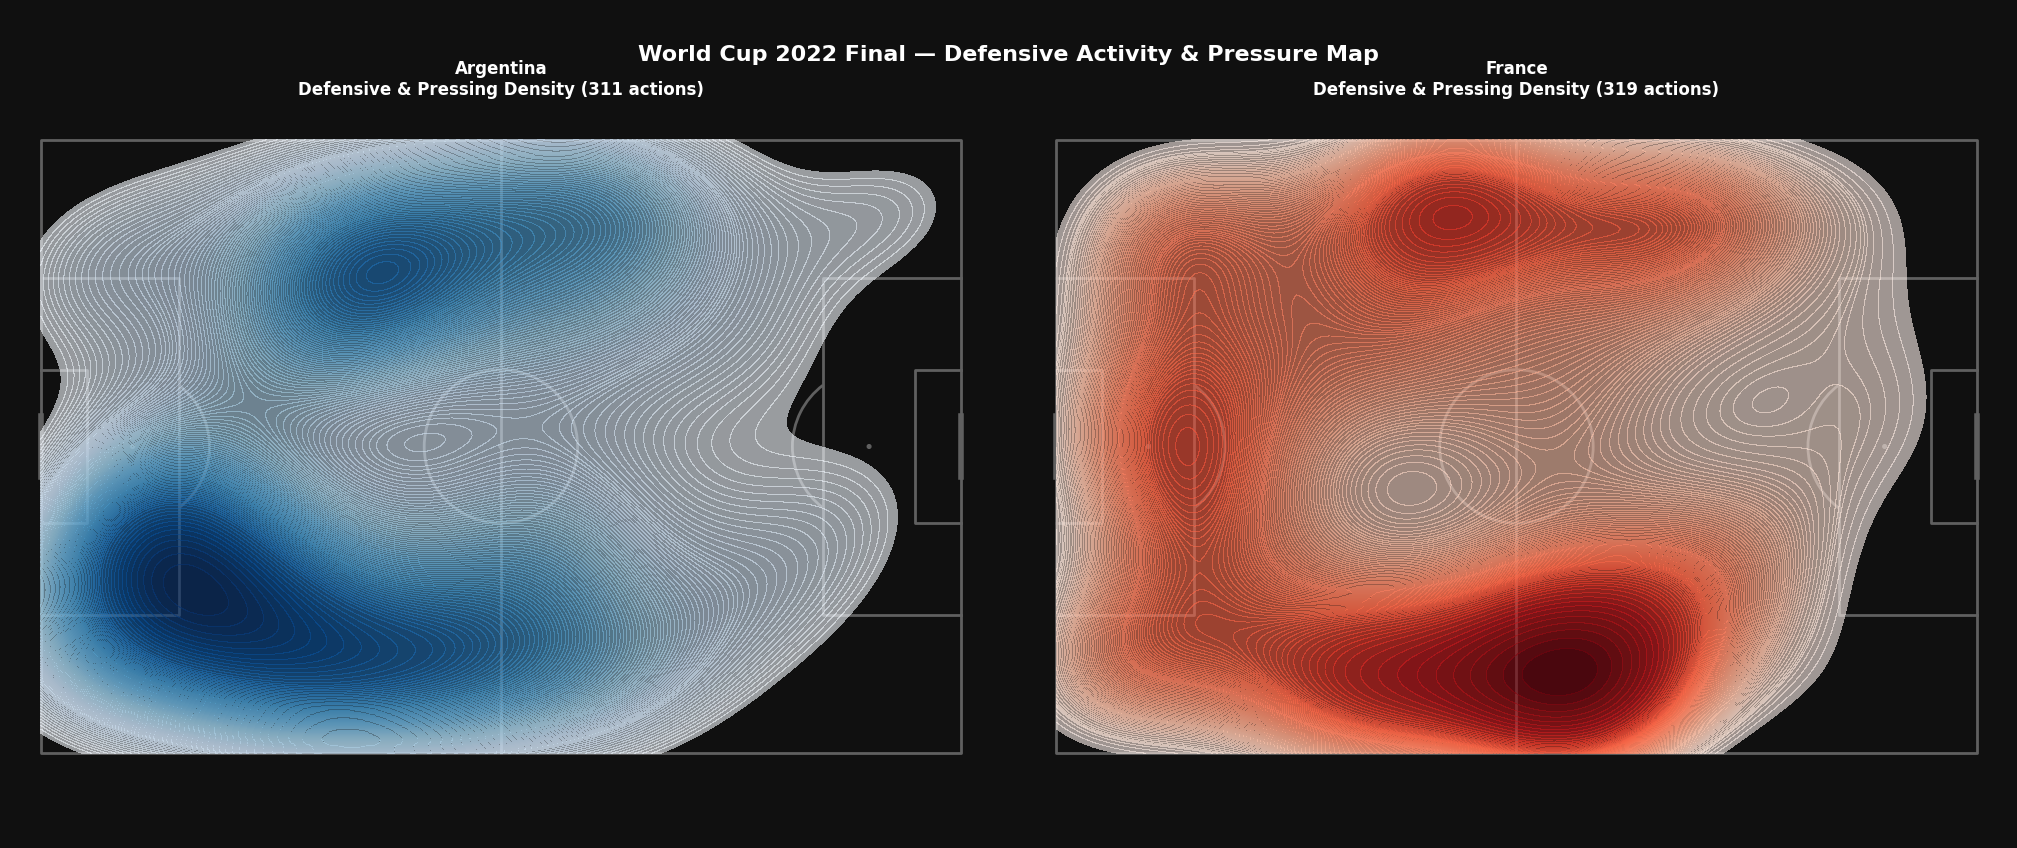

In [15]:
# 1. Filtriamo le azioni difensive: Pressioni, Contrasti, Intercetti, Falli e Blocchi
defensive_actions = events[
    (events['type'].isin(['Pressure', 'Duel', 'Interception', 'Foul Committed', 'Clearance', 'Block'])) &
    (events['period'] <= 4)
].copy()

defensive_actions['x'] = defensive_actions['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
defensive_actions['y'] = defensive_actions['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
defensive_actions = defensive_actions.dropna(subset=['x', 'y'])

# 2. Configurazione Pitch doppio (affiancati)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#101010', line_color='#606060')
fig, axs = pitch.grid(nrows=1, ncols=2, grid_height=0.75, title_height=0.1,
                      endnote_height=0.05, axis=False)
fig.set_facecolor('#101010')

teams = ['Argentina', 'France']
cmaps = {'Argentina': 'Blues', 'France': 'Reds'}

for ax, team in zip(axs['pitch'], teams):
    team_actions = defensive_actions[defensive_actions['team'] == team]

    # Mappa di densità Kernel Density Estimation (KDE)
    kde = pitch.kdeplot(team_actions.x, team_actions.y, ax=ax,
                        levels=100, fill=True, cmap=cmaps[team],
                        alpha=0.6, cut=4)

    ax.set_title(f"{team}\nDefensive & Pressing Density ({len(team_actions)} actions)",
                 color='#ffffff', fontsize=12, weight='bold', pad=10)

axs['title'].text(0.5, 0.5, 'World Cup 2022 Final — Defensive Activity & Pressure Map',
                  ha='center', va='center', fontsize=16, color='#ffffff', weight='bold')

plt.savefig('defensive_activity_map.png', dpi=300, bbox_inches='tight', facecolor='#101010')
plt.show()